In [2]:
import os
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("=== 1. قراءة البيانات ===")
train_df = pd.read_csv("train-test.csv")
val_df = pd.read_csv("validation.csv")
dec_df = pd.read_csv("december-chart-inputs.csv")

# تجهيز التواريخ
for df in [train_df, val_df, dec_df]:
    df['date'] = pd.to_datetime(df['date'])

# إنشاء ميزة Lane (المسار)
train_df['lane'] = train_df['pickup'] + " -> " + train_df['delivery']
val_df['lane'] = val_df['pickup'] + " -> " + val_df['delivery']
dec_df['lane'] = dec_df['pickup'] + " -> " + dec_df['delivery']

# استكمال القيم المفقودة في ديسمبر إذا لزم الأمر
if 'pickup_lat' not in dec_df.columns:
    # استخراج الإحداثيات والمؤشرات الخاصة بمسار Lexington -> Fort Wayne من بيانات التدريب
    sample = train_df[train_df['lane'] == "Lexington -> Fort Wayne"].iloc[0]
    dec_df['pickup_lat'] = sample['pickup_lat']
    dec_df['pickup_lon'] = sample['pickup_lon']
    dec_df['delivery_lat'] = sample['delivery_lat']
    dec_df['delivery_lon'] = sample['delivery_lon']
    dec_df['market_index'] = train_df['market_index'].median()
    dec_df['quote_signal'] = train_df['quote_signal'].median()

# معالجة القيم المفقودة (Imputation)
for df in [train_df, val_df, dec_df]:
    df['weight'] = df['weight'].fillna(train_df['weight'].median())
    df['market_index'] = df['market_index'].fillna(train_df['market_index'].median())

print("=== 2. هندسة الميزات (Feature Engineering) ===")
def add_features(df):
    df = df.copy()
    # ميزات التاريخ والوقت
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek
    df['dayofyear'] = df['date'].dt.dayofyear
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

    # ميزات المسافة والوزن
    df['weight_per_mile'] = df['weight'] / (df['distance'] + 1e-5)

    # ترميز الأعمدة النصية إلى تصنيفات (Categorical)
    for col in ['pickup', 'delivery', 'equipment', 'lane']:
        df[col] = df[col].astype('category')
    return df

train_feats = add_features(train_df)
val_feats = add_features(val_df)
dec_feats = add_features(dec_df)

features = [
    'pickup', 'delivery', 'lane', 'equipment',
    'pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon',
    'distance', 'weight', 'market_index', 'quote_signal',
    'month', 'day', 'dayofweek', 'dayofyear', 'is_weekend', 'weight_per_mile'
]
categorical_features = ['pickup', 'delivery', 'lane', 'equipment']
target = 'posted_rate'

print("=== 3. تقسيم البيانات زمانياً (Time-Based Split) ===")
# استخدام التواريخ الأخيرة من بيانات التدريب للـ Validation
split_date = pd.to_datetime('2025-09-01')
train_split = train_feats[train_feats['date'] < split_date]
valid_split = train_feats[train_feats['date'] >= split_date]

X_tr, y_tr = train_split[features], train_split[target]
X_val, y_val = valid_split[features], valid_split[target]

print(f"صفوف التدريب: {len(X_tr)} | صفوف التقييم: {len(X_val)}")

print("=== 4. تدريب النموذج (LightGBM) ===")
model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)

model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

val_preds = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, val_preds))
mae = mean_absolute_error(y_val, val_preds)
print(f"نتائج التقييم الداخلي -> RMSE: {rmse:.2f} | MAE: {mae:.2f}")

print("=== 5. إعادة التدريب على كل البيانات والتنبؤ ===")
final_model = lgb.LGBMRegressor(
    n_estimators=model.best_iteration_ or 500,
    learning_rate=0.03,
    num_leaves=31,
    random_state=42,
    verbosity=-1
)
final_model.fit(train_feats[features], train_feats[target])

# التنبؤ لملف Validation
val_feats['predicted_rate'] = final_model.predict(val_feats[features])
validation_predictions = val_feats[['load_id', 'predicted_rate']]
validation_predictions.to_csv("validation_predictions.csv", index=False)
print(" تم حفظ ملف: validation_predictions.csv")

# التنبؤ لشهر ديسمبر
dec_feats['predicted_rate'] = final_model.predict(dec_feats[features])
december_outputs = dec_feats[['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']]
december_outputs['date'] = december_outputs['date'].dt.strftime('%Y-%m-%d')

# التأكد من مجلد data
os.makedirs("data", exist_ok=True)
december_outputs.to_csv("data/december_chart_inputs.csv", index=False)
print(" تم حفظ ملف: data/december_chart_inputs.csv")

=== 1. قراءة البيانات ===
=== 2. هندسة الميزات (Feature Engineering) ===
=== 3. تقسيم البيانات زمانياً (Time-Based Split) ===
صفوف التدريب: 38477 | صفوف التقييم: 9523
=== 4. تدريب النموذج (LightGBM) ===
نتائج التقييم الداخلي -> RMSE: 643.34 | MAE: 142.73
=== 5. إعادة التدريب على كل البيانات والتنبؤ ===
 تم حفظ ملف: validation_predictions.csv
 تم حفظ ملف: data/december_chart_inputs.csv


/tmp/ipykernel_3114/3948331264.py:118: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  december_outputs['date'] = december_outputs['date'].dt.strftime('%Y-%m-%d')


In [4]:
!python score.py --predictions validation_predictions.csv --december-predictions data/december_chart_inputs.csv

python3: can't open file '/content/score.py': [Errno 2] No such file or directory


In [5]:
%%writefile score.py
from __future__ import annotations

import argparse
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

EXPECTED_ROWS = 12_000
EXPECTED_IDS = {f"TE-{index:06d}" for index in range(1, EXPECTED_ROWS + 1)}
DECEMBER_DATES = pd.date_range("2025-12-01", "2025-12-31", freq="D")
FIXED_PICKUP = "Lexington"
FIXED_DELIVERY = "Fort Wayne"
FIXED_DISTANCE = 360.0
FIXED_EQUIPMENT = "Dry Van"
FIXED_WEIGHT = 32_000.0

def fail(message: str) -> None:
    raise SystemExit(f"ERROR: {message}")

def read_csv(path: Path, label: str) -> pd.DataFrame:
    if not path.is_file():
        fail(f"{label} file not found: {path}")
    try:
        return pd.read_csv(path)
    except Exception as exc:
        fail(f"could not read {label}: {exc}")

def numeric_series(frame: pd.DataFrame, column: str, label: str) -> pd.Series:
    values = pd.to_numeric(frame[column], errors="coerce")
    if values.isna().any() or not np.isfinite(values).all():
        fail(f"{label} contains invalid {column} values")
    return values.astype(float)

def validate_predictions(predictions: pd.DataFrame) -> None:
    if list(predictions.columns) != ["load_id", "predicted_rate"]:
        fail("predictions must contain exactly two columns in this order: load_id,predicted_rate")
    if len(predictions) != EXPECTED_ROWS:
        fail(f"predictions must contain exactly {EXPECTED_ROWS:,} rows")
    if predictions["load_id"].isna().any() or predictions["load_id"].duplicated().any():
        fail("predictions contains missing or duplicate load_id values")

    submitted_ids = set(predictions["load_id"].astype(str))
    missing = EXPECTED_IDS - submitted_ids
    extra = submitted_ids - EXPECTED_IDS
    if missing or extra:
        fail(
            "prediction IDs do not match the validation set "
            f"(missing={len(missing)}, extra={len(extra)})"
        )

    predicted_rate = numeric_series(predictions, "predicted_rate", "predictions")
    if (predicted_rate <= 0).any():
        fail("predictions contains non-positive predicted_rate values")

def validate_december(frame: pd.DataFrame) -> pd.DataFrame:
    columns = ["pickup", "delivery", "distance", "equipment", "weight", "date", "predicted_rate"]
    if list(frame.columns) != columns:
        fail("December predictions must keep the original seven columns and column order")

    result = frame.copy()
    result["date"] = pd.to_datetime(result["date"], errors="coerce")
    if result["date"].isna().any():
        fail("December predictions contains invalid dates")
    result["distance"] = numeric_series(result, "distance", "December predictions")
    result["weight"] = numeric_series(result, "weight", "December predictions")
    result["predicted_rate"] = numeric_series(result, "predicted_rate", "December predictions")

    if result["date"].duplicated().any():
        fail("December predictions contains duplicate dates")
    if len(result) != 31 or set(result["date"]) != set(DECEMBER_DATES):
        fail("December predictions must contain one row for every day from 2025-12-01 to 2025-12-31")
    if not result["pickup"].eq(FIXED_PICKUP).all():
        fail(f"December pickup must be {FIXED_PICKUP} for all rows")
    if not result["delivery"].eq(FIXED_DELIVERY).all():
        fail(f"December delivery must be {FIXED_DELIVERY} for all rows")
    if not np.isclose(result["distance"], FIXED_DISTANCE).all():
        fail(f"December distance must be {FIXED_DISTANCE:g} for all rows")
    if not result["equipment"].eq(FIXED_EQUIPMENT).all():
        fail(f"December equipment must be {FIXED_EQUIPMENT} for all rows")
    if not np.isclose(result["weight"], FIXED_WEIGHT).all():
        fail(f"December weight must be {FIXED_WEIGHT:g} for all rows")
    if (result["predicted_rate"] <= 0).any():
        fail("December predicted_rate values must be positive")
    return result.sort_values("date")

def save_december_chart(december: pd.DataFrame, output: Path) -> None:
    figure, axis = plt.subplots(figsize=(10.8, 4.8), dpi=180)
    color = "#064A56"
    axis.plot(
        december["date"],
        december["predicted_rate"],
        color=color,
        linewidth=2.6,
        marker="o",
        markersize=3.2,
    )
    floor = float(december["predicted_rate"].min())
    axis.fill_between(
        december["date"],
        december["predicted_rate"],
        floor - max(10.0, floor * 0.02),
        color=color,
        alpha=0.08,
    )
    axis.set_title("Candidate: December 2025 Predicted Load Rate", loc="left", fontsize=15, fontweight="bold", pad=12)
    axis.set_ylabel("Predicted rate ($)")
    axis.grid(axis="y", color="#D9E2E4", linewidth=0.8)
    axis.spines[["top", "right"]].set_visible(False)
    axis.spines[["left", "bottom"]].set_color("#9DAFB3")
    axis.tick_params(axis="x", rotation=35)
    axis.text(
        0,
        -0.40,
        "Fixed inputs: Lexington to Fort Wayne | 360 miles | Dry Van | 32,000 lb | only date changes",
        transform=axis.transAxes,
        fontsize=9.5,
        color="#455A60",
    )
    figure.tight_layout(rect=(0, 0.12, 1, 1))
    figure.savefig(output, bbox_inches="tight")
    plt.close(figure)

def main() -> None:
    parser = argparse.ArgumentParser(
        description="Validate candidate output files and generate the fixed December chart."
    )
    parser.add_argument("--predictions", required=True, help="CSV with load_id,predicted_rate")
    parser.add_argument(
        "--december-predictions",
        required=True,
        help="Completed data/december_chart_inputs.csv",
    )
    parser.add_argument("--output-dir", default="scorer_results")
    args = parser.parse_args()

    validate_predictions(read_csv(Path(args.predictions), "predictions"))
    december = validate_december(read_csv(Path(args.december_predictions), "December predictions"))
    output = Path(args.output_dir)
    output.mkdir(parents=True, exist_ok=True)
    chart = output / "candidate_december.png"
    save_december_chart(december, chart)

    print(f"Validated {EXPECTED_ROWS:,} final predictions.")
    print("Validated 31 fixed December predictions.")
    print(f"Created chart: {chart}")
    print("Final validation metrics are calculated by Spotter after submission.")

if __name__ == "__main__":
    main()

Writing score.py


In [6]:
!python score.py --predictions!python score.py --predictions validation_predictions.csv --december-predictions data/december_chart_inputs.csv validation_predictions.csv --december-predictions data/december_chart_inputs.csv

usage: score.py [-h] --predictions PREDICTIONS
                --december-predictions DECEMBER_PREDICTIONS
                [--output-dir OUTPUT_DIR]
score.py: error: unrecognized arguments: --predictions!python score.py validation_predictions.csv


In [8]:
!python score.py --predictions validation_predictions.csv --december-predictions data/december_chart_inputs.csv


Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.


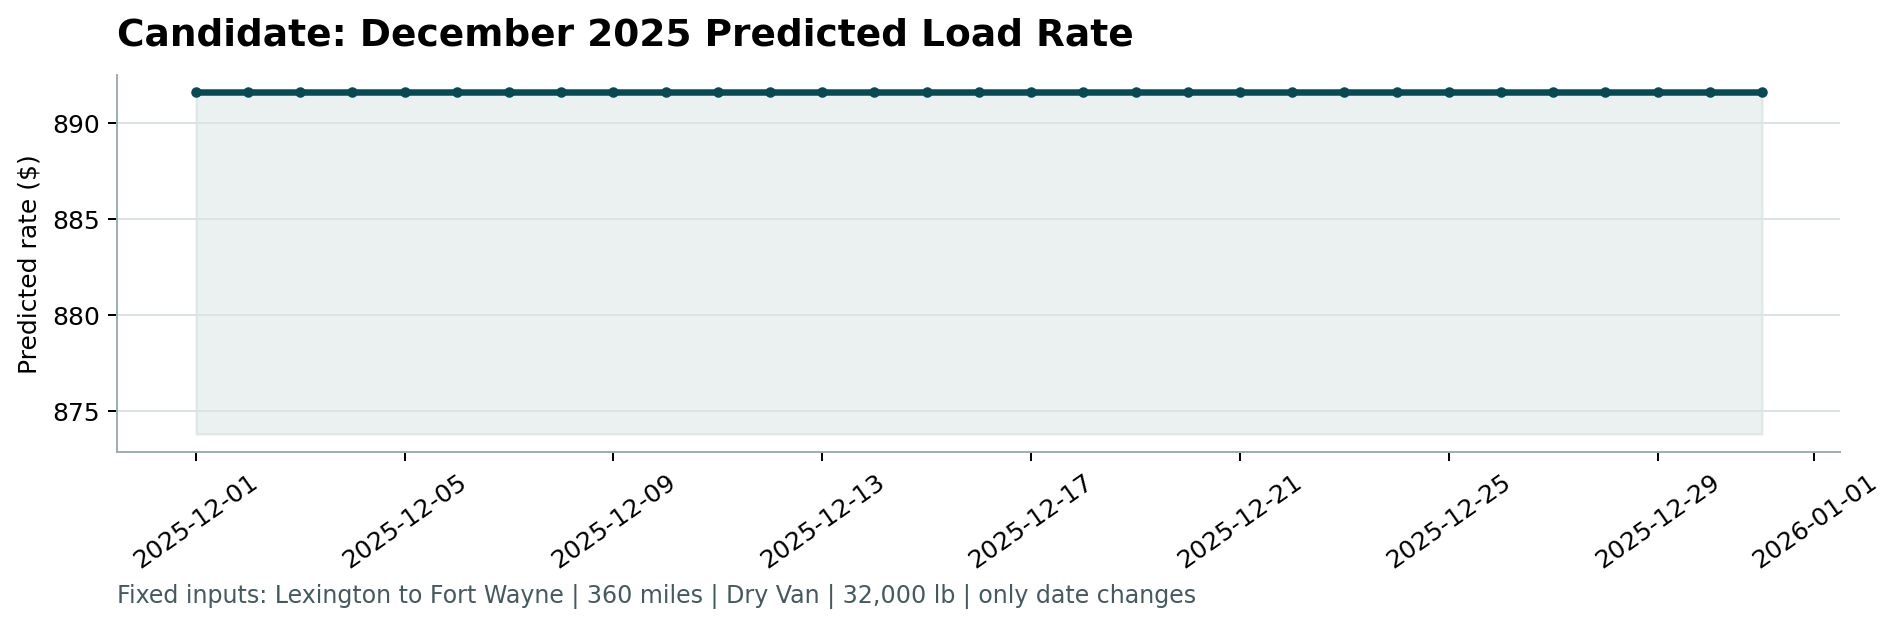

In [9]:
from IPython.display import Image, display

display(Image(filename="scorer_results/candidate_december.png"))